# 4. Preprocesamiento y modelo base

Este capítulo cubre la sección 2.9 (preprocesamiento) y la sección 3 (modelo base) del
enunciado: regresión logística dentro de un `Pipeline`, comparada con líneas base triviales,
validada con bloques temporales y evaluada una sola vez en el conjunto de prueba reservado.

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, "../src")
# Los procesos paralelos de joblib necesitan encontrar el módulo utils
os.environ["PYTHONPATH"] = os.path.abspath("../src") + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, GroupKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, SplineTransformer, StandardScaler

import utils as u

u.estilo()
pd.set_option("display.width", 160)
np.random.seed(u.SEMILLA)

panel = u.cargar_panel()
train, test = u.particion(panel)
del panel
Y = u.VAR_OBJETIVO
y_tr, y_te = train[Y].to_numpy(), test[Y].to_numpy()
print(f"Entrenamiento: {len(train):,} filas; prueba: {len(test):,} filas")

Entrenamiento: 622,244 filas; prueba: 103,466 filas


## 4.1 Preprocesamiento (sección 2.9)

Todo el preprocesamiento vive dentro de un `Pipeline` y se ajusta solo con los datos de
entrenamiento de cada pliegue. Cada decisión remite a un resultado del EDA:

| Paso | Variables | Decisión | Resultado del EDA que la motiva |
|---|---|---|---|
| Imputación | todas las numéricas | mediana de entrenamiento | Único faltante: `ratio_t_1` (0,03 %), semanas *t-1* sin encuesta, faltante MAR por diseño (1.7.1) |
| Transformación log | `n_envios8`, `n_alimentos8`, `dist_km`, `antig_sem` | `log1p` | Asimetría de 8,0, 4,0 y 1,7 (2.2) |
| Winsorización | numéricas continuas | recorte en percentiles 1 y 99 aprendidos en train | Colas largas y outliers genuinos que no deben eliminarse (1.7.4, 2.2, 2.4) |
| Splines cúbicos | `ratio_t`, `ratio_t_1` | 5 nodos en cuantiles | Relación en forma de U con el objetivo (2.3) |
| Escalado | numéricas | `StandardScaler` | Escalas muy distintas; la regularización L2 exige escalas comparables |
| Codificación | `mercado`, `depto_origen`, `grupo_dom` | one-hot; categorías < 1 % agrupadas como "infrecuente" | 6-8 categorías raras por variable (2.2) |
| Composición | `sh_*` | se omite `sh_procesados` | Las participaciones suman 1 (VIF, 2.3) |
| Regularización | todas | L2 con C elegido por validación temporal | Correlaciones altas entre tamaño y regularidad (2.3) |
| Calendario | `festivos_t1`, `sem_sin`, `sem_cos` | incluidas | Estacionalidad anual y efecto de festivos (2.6) |
| Espaciales | `dist_km`, `mismo_depto`, `local`, `depto_origen`, `pdet_origen` | incluidas; sin lat/lon crudas | Heterogeneidad espacial sin memorizar ubicaciones (2.7) |
| Excluidas | `tasa_t1`, `cod_mpio`, días de encuesta en *t+1* | fuera del modelo | Auditoría de fuga (2.5) |

In [2]:
LOG = ["n_envios8", "n_alimentos8", "dist_km", "antig_sem"]
SPL = ["ratio_t", "ratio_t_1"]
NUM = [c for c in u.NUMERICAS if c not in LOG + SPL + ["sh_procesados"]]
BIN = u.BINARIAS
CAT = u.CATEGORICAS
X_COLS = LOG + SPL + NUM + BIN + CAT

def preprocesador():
    return ColumnTransformer([
        ("log", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("win", u.Winsorizador()), ("esc", StandardScaler())]), LOG),
        ("spl", Pipeline([("imp", SimpleImputer(strategy="median")), ("win", u.Winsorizador()),
                          ("spl", SplineTransformer(n_knots=5, degree=3, knots="quantile")),
                          ("esc", StandardScaler())]), SPL),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("win", u.Winsorizador()),
                          ("esc", StandardScaler())]), NUM),
        ("bin", "passthrough", BIN),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01), CAT),
    ])

modelo = Pipeline([("prep", preprocesador()),
                   ("clf", LogisticRegression(max_iter=3000, random_state=u.SEMILLA))])
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('spl', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

## 4.2 Esquema de validación

**Esquema principal (futuro de corredores conocidos).** Validación cruzada de ventana
creciente sobre semanas completas (`TimeSeriesSplit` aplicado a las semanas), con 5 pliegues y un
hueco de 8 semanas entre entrenamiento y validación. Es el mismo tipo de partición que la
separación train/test (cronológica con hueco).

**Esquema secundario (territorios nuevos).** `GroupKFold` con el departamento de origen como
grupo: el modelo se evalúa en departamentos que no vio al entrenar.

In [3]:
cv = u.BloquesTemporales(n_splits=5, gap_semanas=8)
for i, (a, b) in enumerate(cv.split(train)):
    print(f"Pliegue {i + 1}: train {train['semana_t1'].iloc[a].min().date()} a {train['semana_t1'].iloc[a].max().date()} "
          f"({len(a):,})  |  validación {train['semana_t1'].iloc[b].min().date()} a {train['semana_t1'].iloc[b].max().date()} ({len(b):,})")

Pliegue 1: train 2018-01-29 a 2019-02-04 (92,057)  |  validación 2019-04-08 a 2020-05-11 (100,071)
Pliegue 2: train 2018-01-29 a 2020-03-16 (192,880)  |  validación 2020-05-18 a 2021-06-21 (99,844)
Pliegue 3: train 2018-01-29 a 2021-04-26 (292,964)  |  validación 2021-06-28 a 2022-08-01 (103,016)


Pliegue 4: train 2018-01-29 a 2022-06-06 (395,088)  |  validación 2022-08-08 a 2023-09-11 (103,252)
Pliegue 5: train 2018-01-29 a 2023-07-17 (497,700)  |  validación 2023-09-18 a 2024-10-21 (109,785)


## 4.3 Ajuste del hiperparámetro de regularización

In [4]:
Xtr = train[X_COLS + ["semana_t1"]]
Xte = test[X_COLS + ["semana_t1"]]
t0 = time.time()
busqueda = GridSearchCV(modelo, {"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]}, cv=cv,
                        scoring={"roc_auc": "roc_auc", "average_precision": "average_precision",
                                 "neg_log_loss": "neg_log_loss"},
                        refit="roc_auc", n_jobs=-1, return_train_score=True)
busqueda.fit(Xtr, y_tr)
print(f"Tiempo: {time.time() - t0:.0f} s")
res = pd.DataFrame(busqueda.cv_results_)
tabla_c = res[["param_clf__C", "mean_train_roc_auc", "mean_test_roc_auc", "std_test_roc_auc",
               "mean_test_average_precision", "mean_test_neg_log_loss"]].rename(columns=lambda c: c.replace("mean_", ""))
tabla_c.round(4)

Tiempo: 53 s


,param_clf__C,train_roc_auc,test_roc_auc,std_test_roc_auc,test_average_precision,test_neg_log_loss
0,0.001,0.7833,0.7809,0.0026,0.5498,-0.4902
1,0.010,0.7836,0.7810,0.0027,0.5492,-0.4900
2,0.100,0.7836,0.7809,0.0028,0.5489,-0.4900
3,1.000,0.7836,0.7809,0.0028,0.5488,-0.4901
4,10.000,0.7836,0.7809,0.0028,0.5488,-0.4901


In [5]:
mejor = busqueda.best_estimator_
C_opt = busqueda.best_params_["clf__C"]
print(f"C elegido: {C_opt}")
por_pliegue = res.loc[busqueda.best_index_, [f"split{i}_test_roc_auc" for i in range(5)]].astype(float)
print("AUC de validación por pliegue:", por_pliegue.round(4).to_list())

C elegido: 0.01
AUC de validación por pliegue: [0.7796, 0.7771, 0.7802, 0.7843, 0.7838]


## 4.4 Umbral de decisión

La regresión logística entrega probabilidades. El umbral que convierte probabilidades en
alertas se elige con las predicciones fuera de pliegue del entrenamiento (maximizando F1), nunca
con el conjunto de prueba.

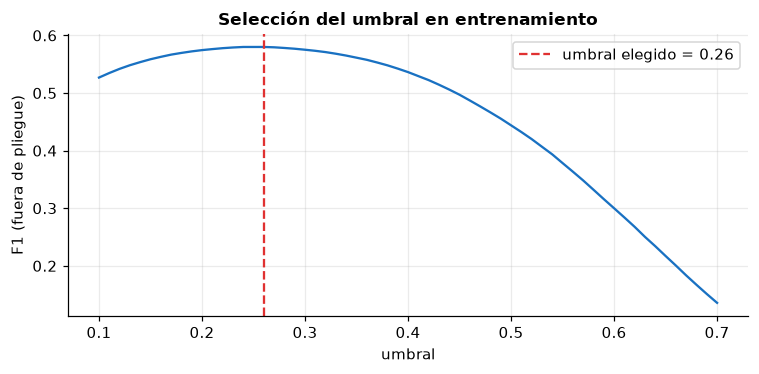

Umbral que maximiza F1 fuera de pliegue: 0.26 (F1 = 0.580)


In [6]:
oof_p, oof_y = [], []
for a, b in cv.split(train):
    m = Pipeline([("prep", preprocesador()),
                  ("clf", LogisticRegression(C=C_opt, max_iter=3000, random_state=u.SEMILLA))])
    m.fit(Xtr.iloc[a], y_tr[a])
    oof_p.append(m.predict_proba(Xtr.iloc[b])[:, 1])
    oof_y.append(y_tr[b])
oof_p, oof_y = np.concatenate(oof_p), np.concatenate(oof_y)
umbrales = np.linspace(0.1, 0.7, 61)
f1s = [f1_score(oof_y, oof_p >= t) for t in umbrales]
UMBRAL = float(umbrales[int(np.argmax(f1s))])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(umbrales, f1s, color="#1971c2")
ax.axvline(UMBRAL, color="#e03131", ls="--", label=f"umbral elegido = {UMBRAL:.2f}")
ax.set_xlabel("umbral")
ax.set_ylabel("F1 (fuera de pliegue)")
ax.set_title("Selección del umbral en entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Umbral que maximiza F1 fuera de pliegue: {UMBRAL:.2f} (F1 = {max(f1s):.3f})")

## 4.5 Líneas base triviales

* `DummyClassifier(strategy="most_frequent")`: siempre predice "sin interrupción".
* `DummyClassifier(strategy="stratified")`: predice al azar con la proporción de clases de
  entrenamiento.
* **Persistencia**, la línea base natural en series de tiempo: predice interrupción en *t+1* si
  el corredor ya estaba por debajo del 50 % de su promedio en *t* (`ratio_t < 0,5`); su puntaje
  para el AUC es `-ratio_t`.

In [7]:
dummy_mf = DummyClassifier(strategy="most_frequent").fit(Xtr, y_tr)
dummy_st = DummyClassifier(strategy="stratified", random_state=u.SEMILLA).fit(Xtr, y_tr)
p_log = mejor.predict_proba(Xte)[:, 1]
modelos = {
    "Dummy (clase mayoritaria)": (dummy_mf.predict_proba(Xte)[:, 1], dummy_mf.predict(Xte)),
    "Dummy (estratificado)": (dummy_st.predict_proba(Xte)[:, 1], dummy_st.predict(Xte)),
    "Persistencia (ratio_t < 0,5)": (-test["ratio_t"].to_numpy(), (test["ratio_t"] < 0.5).astype(int).to_numpy()),
    "Regresión logística (umbral 0,5)": (p_log, (p_log >= 0.5).astype(int)),
    f"Regresión logística (umbral {UMBRAL:.2f})".replace(".", ","): (p_log, (p_log >= UMBRAL).astype(int)),
}

## 4.6 Evaluación en el conjunto de prueba (2025)

Los intervalos de confianza al 95 % se obtienen con **bootstrap por bloques de semana** (500
réplicas): se remuestrean semanas completas para respetar la dependencia entre corredores de la
misma semana, que el análisis temporal mostró (choques comunes).

In [8]:
sem_te = test["semana_t1"].to_numpy()
metricas = {
    "accuracy": lambda y, s, p: accuracy_score(y, p),
    "precision": lambda y, s, p: precision_score(y, p, zero_division=0),
    "recall": lambda y, s, p: recall_score(y, p),
    "F1": lambda y, s, p: f1_score(y, p),
    "AUC-ROC": lambda y, s, p: roc_auc_score(y, s),
    "AUC-PR": lambda y, s, p: average_precision_score(y, s),
}
filas = []
for nombre, (s, pr) in modelos.items():
    fila = {"modelo": nombre}
    for mn, f in metricas.items():
        fila[mn] = f(y_te, s, pr)
    filas.append(fila)
tabla = pd.DataFrame(filas).set_index("modelo")
tabla.round(4)

,accuracy,precision,recall,F1,AUC-ROC,AUC-PR
modelo,,,,,,
Dummy (clase mayoritaria),0.7396,0.0000,0.0000,0.0000,0.5000,0.2604
Dummy (estratificado),0.6053,0.2613,0.2820,0.2713,0.5006,0.2607
"Persistencia (ratio_t < 0,5)",0.7252,0.4675,0.3978,0.4298,0.5838,0.3890
"Regresión logística (umbral 0,5)",0.7661,0.5834,0.3561,0.4422,0.7930,0.5386
"Regresión logística (umbral 0,26)",0.7008,0.4556,0.7629,0.5705,0.7930,0.5386


In [9]:
def ic(nombre, mn, B=500):
    s, pr = modelos[nombre]
    f = metricas[mn]
    rng = np.random.default_rng(u.SEMILLA)
    grupos = pd.Series(np.arange(len(y_te))).groupby(sem_te).apply(np.array).to_list()
    vals = []
    for _ in range(B):
        idx = np.concatenate([grupos[i] for i in rng.integers(0, len(grupos), len(grupos))])
        vals.append(f(y_te[idx], s[idx], pr[idx]))
    return np.percentile(vals, [2.5, 97.5])

filas = []
for nombre in modelos:
    fila = {"modelo": nombre}
    for mn in ["accuracy", "F1", "recall", "AUC-ROC", "AUC-PR"]:
        lo, hi = ic(nombre, mn)
        fila[mn] = f"{tabla.loc[nombre, mn]:.3f} [{lo:.3f}, {hi:.3f}]"
    filas.append(fila)
pd.DataFrame(filas).set_index("modelo")

,accuracy,F1,recall,AUC-ROC,AUC-PR
modelo,,,,,
Dummy (clase mayoritaria),"0.740 [0.733, 0.746]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.500 [0.500, 0.500]","0.260 [0.254, 0.267]"
Dummy (estratificado),"0.605 [0.601, 0.610]","0.271 [0.265, 0.277]","0.282 [0.277, 0.287]","0.501 [0.497, 0.504]","0.261 [0.254, 0.268]"
"Persistencia (ratio_t < 0,5)","0.725 [0.719, 0.730]","0.430 [0.423, 0.437]","0.398 [0.387, 0.410]","0.584 [0.579, 0.589]","0.389 [0.381, 0.399]"
"Regresión logística (umbral 0,5)","0.766 [0.761, 0.770]","0.442 [0.432, 0.453]","0.356 [0.344, 0.370]","0.793 [0.789, 0.797]","0.539 [0.530, 0.549]"
"Regresión logística (umbral 0,26)","0.701 [0.696, 0.705]","0.570 [0.564, 0.577]","0.763 [0.755, 0.771]","0.793 [0.789, 0.797]","0.539 [0.530, 0.549]"


In [10]:
nombre_log = f"Regresión logística (umbral {UMBRAL:.2f})".replace(".", ",")
dif = []
rng = np.random.default_rng(u.SEMILLA)
grupos = pd.Series(np.arange(len(y_te))).groupby(sem_te).apply(np.array).to_list()
s_per = modelos["Persistencia (ratio_t < 0,5)"][0]
for _ in range(500):
    idx = np.concatenate([grupos[i] for i in rng.integers(0, len(grupos), len(grupos))])
    dif.append(roc_auc_score(y_te[idx], p_log[idx]) - roc_auc_score(y_te[idx], s_per[idx]))
lo, hi = np.percentile(dif, [2.5, 97.5])
print(f"Diferencia de AUC (logística − persistencia): {np.mean(dif):.3f}, IC 95 % [{lo:.3f}, {hi:.3f}]")
print(f"Brier score logística: {brier_score_loss(y_te, p_log):.4f}; "
      f"Brier de la predicción constante (tasa de train): {brier_score_loss(y_te, np.full(len(y_te), y_tr.mean())):.4f}")

Diferencia de AUC (logística − persistencia): 0.209, IC 95 % [0.203, 0.215]
Brier score logística: 0.1537; Brier de la predicción constante (tasa de train): 0.1931


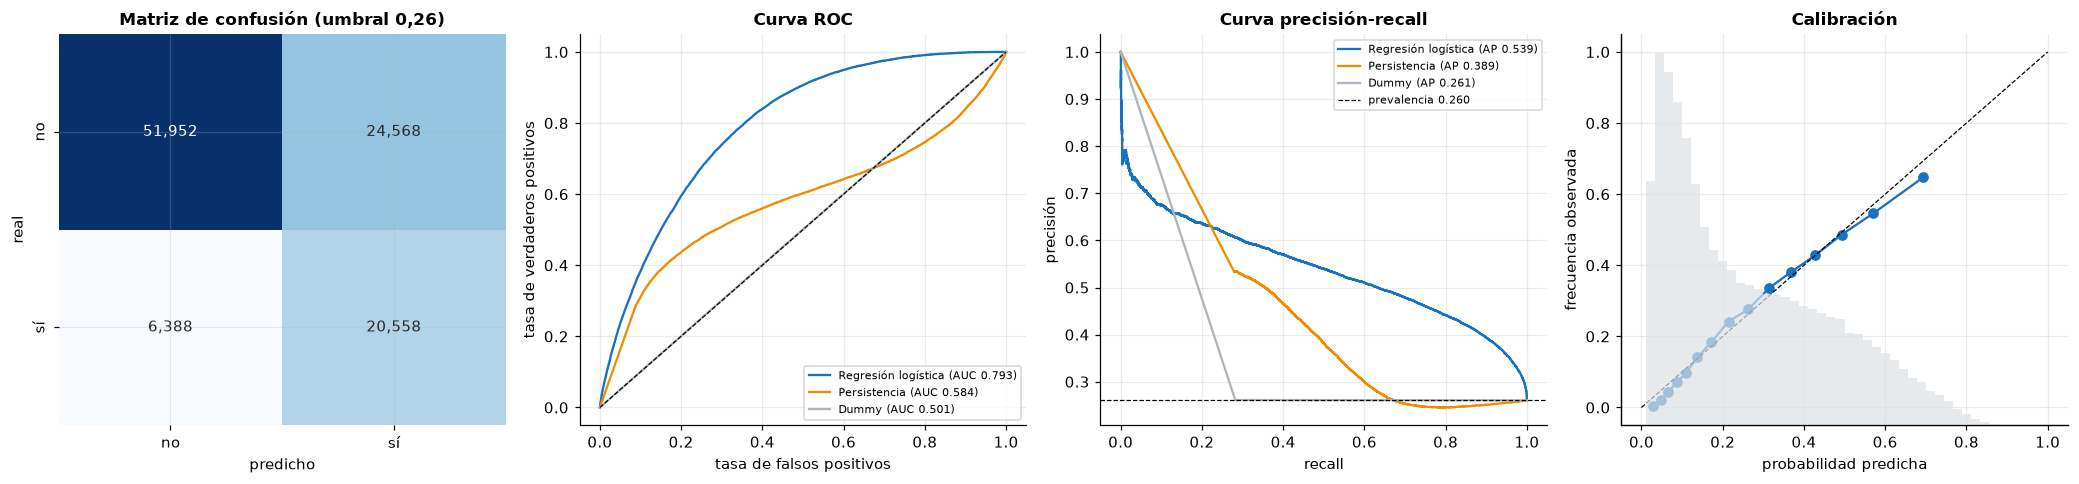

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
cm = confusion_matrix(y_te, (p_log >= UMBRAL).astype(int))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["no", "sí"], yticklabels=["no", "sí"])
axes[0].set_xlabel("predicho")
axes[0].set_ylabel("real")
axes[0].set_title(f"Matriz de confusión (umbral {UMBRAL:.2f})".replace(".", ","))
for nombre, color in [("Regresión logística (umbral 0,5)", "#1971c2"), ("Persistencia (ratio_t < 0,5)", "#f08c00"),
                      ("Dummy (estratificado)", "#adb5bd")]:
    s = modelos[nombre][0]
    fpr, tpr, _ = roc_curve(y_te, s)
    axes[1].plot(fpr, tpr, color=color, label=f"{nombre.split(' (')[0]} (AUC {roc_auc_score(y_te, s):.3f})")
    pr_, rc_, _ = precision_recall_curve(y_te, s)
    axes[2].plot(rc_, pr_, color=color, label=f"{nombre.split(' (')[0]} (AP {average_precision_score(y_te, s):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("tasa de falsos positivos")
axes[1].set_ylabel("tasa de verdaderos positivos")
axes[1].legend(fontsize=7)
axes[2].axhline(y_te.mean(), color="k", ls="--", lw=0.8, label=f"prevalencia {y_te.mean():.3f}")
axes[2].set_title("Curva precisión-recall")
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precisión")
axes[2].legend(fontsize=7)
fr, mp = calibration_curve(y_te, p_log, n_bins=15, strategy="quantile")
axes[3].plot(mp, fr, "o-", color="#1971c2", label="logística")
axes[3].plot([0, 1], [0, 1], "k--", lw=0.8)
ax2 = axes[3].twinx()
ax2.hist(p_log, bins=40, color="#dee2e6", alpha=0.7)
ax2.set_yticks([])
ax2.grid(False)
axes[3].set_title("Calibración")
axes[3].set_xlabel("probabilidad predicha")
axes[3].set_ylabel("frecuencia observada")
plt.tight_layout()
plt.show()

**Interpretación.**

* **Validación.** El AUC de validación temporal es prácticamente igual para todos los valores de C
  (0,7809-0,7810) y la brecha entre entrenamiento y validación es de apenas 0,003: con 600 mil
  filas y unas 90 columnas la regularización casi no importa y no hay sobreajuste. El AUC es
  estable entre pliegues (0,777-0,784), incluido el pliegue que contiene el confinamiento y el
  paro nacional.
* **Comparación con la línea base trivial.** En la prueba (todo 2025) la regresión logística
  alcanza AUC-ROC 0,793 [0,789; 0,797] y AUC-PR 0,539 [0,530; 0,549], frente a 0,50 y 0,26 de los
  Dummy. Supera también a la persistencia (AUC 0,584; diferencia 0,209 con IC 95 % [0,203; 0,215]):
  saber que un corredor ya cayó esta semana ayuda poco; lo que más informa es su tamaño y su
  regularidad.
* **Exactitud.** Con umbral 0,5 la exactitud es 0,766, solo 2,6 puntos sobre el 0,740 de predecir
  siempre "sin interrupción". Esto confirma que la exactitud no es la métrica adecuada con este
  desbalance.
* **Umbral.** Con el umbral de 0,26 elegido en entrenamiento, el modelo detecta 76 % de las
  interrupciones (recall 0,763) con una precisión de 0,456 y F1 0,570, frente a 0,43 de la
  persistencia. De cada 100 alertas, unas 46 son interrupciones reales. Para un sistema de alerta
  temprana en abastecimiento es preferible este punto (pocas interrupciones sin detectar) a costa
  de falsas alarmas; el umbral puede ajustarse según el costo relativo de cada error.
* **Calibración.** Las probabilidades están bien calibradas: la curva sigue la diagonal y el Brier
  (0,154) mejora 20 % sobre la predicción constante (0,193). La leve sobreestimación en el decil más
  alto (probabilidad 0,70 frente a 0,65 observada) coincide con la menor tasa de interrupción de
  2025 (26,0 % frente a 28,2 % en entrenamiento).
* **Incertidumbre.** Los intervalos bootstrap por bloques de semana son estrechos (±0,004 en AUC)
  gracias al tamaño de la prueba, aunque respetan la dependencia entre corredores de una misma
  semana.

## 4.7 Validación por bloques espaciales (territorios no vistos)

In [12]:
gkf = GroupKFold(n_splits=5)
filas = []
for i, (a, b) in enumerate(gkf.split(Xtr, y_tr, groups=train["depto_origen"])):
    m = Pipeline([("prep", preprocesador()),
                  ("clf", LogisticRegression(C=C_opt, max_iter=3000, random_state=u.SEMILLA))])
    m.fit(Xtr.iloc[a], y_tr[a])
    s = m.predict_proba(Xtr.iloc[b])[:, 1]
    filas.append({"pliegue": i + 1, "departamentos": train["depto_origen"].iloc[b].nunique(),
                  "filas": len(b), "AUC-ROC": roc_auc_score(y_tr[b], s),
                  "AUC-PR": average_precision_score(y_tr[b], s), "prevalencia": y_tr[b].mean()})
esp = pd.DataFrame(filas).set_index("pliegue")
print(esp.round(4).to_string())
print(f"\nAUC medio por bloques espaciales: {esp['AUC-ROC'].mean():.4f} ± {esp['AUC-ROC'].std():.4f}")
print(f"AUC medio por bloques temporales (C elegido): {por_pliegue.mean():.4f} ± {por_pliegue.std():.4f}")

         departamentos   filas  AUC-ROC  AUC-PR  prevalencia
pliegue                                                     
1                    6  124760   0.7746  0.5691       0.3082
2                    6  124108   0.7794  0.5396       0.2717
3                    6  125037   0.7843  0.5213       0.2526
4                    6  124157   0.7947  0.5554       0.2732
5                    6  124182   0.7677  0.5545       0.3056

AUC medio por bloques espaciales: 0.7801 ± 0.0102
AUC medio por bloques temporales (C elegido): 0.7810 ± 0.0030


## 4.8 Diagnóstico de residuos

En clasificación se usan los residuos de Pearson, $r_i = (y_i - \hat p_i)/\sqrt{\hat p_i(1-\hat p_i)}$.
Si el modelo capturó la estructura, los residuos promedio por semana no deberían estar
autocorrelacionados y los residuos promedio por municipio no deberían tener autocorrelación
espacial.

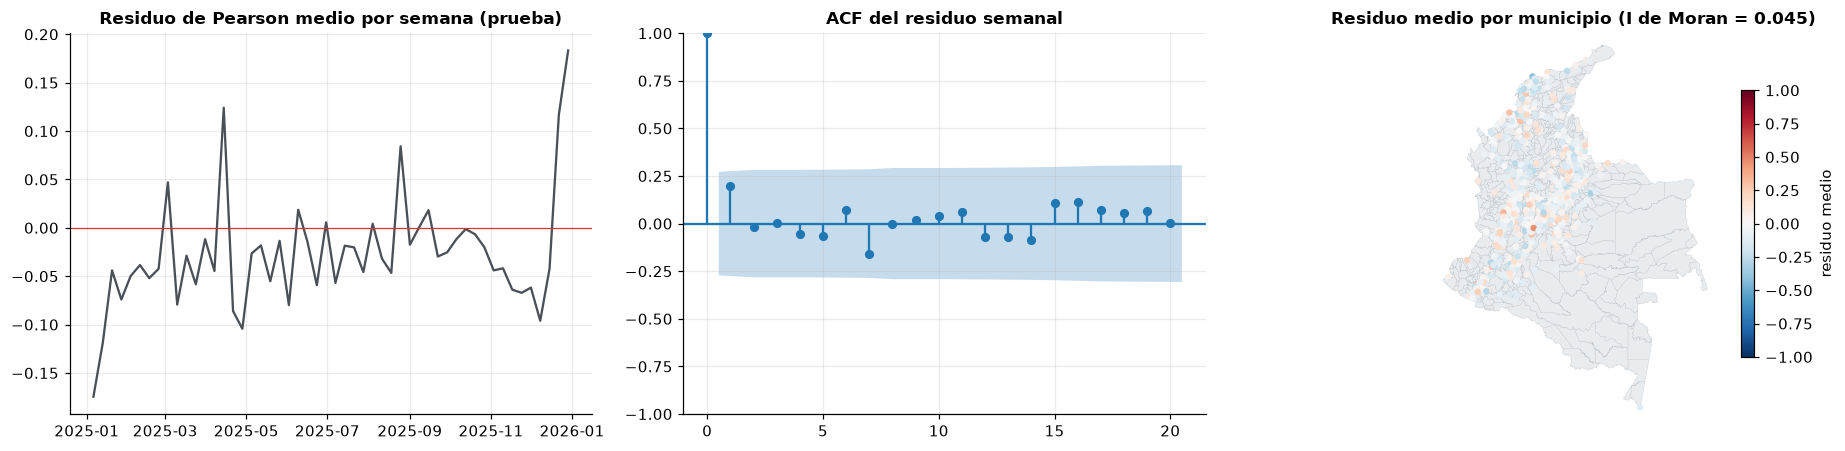

Ljung-Box sobre el residuo semanal:
   lb_stat  lb_pvalue
1   2.1277     0.1447
4   2.3302     0.6753
8   4.4706     0.8124

I de Moran del residuo municipal: 0.045 (p = 0.005); de la tasa observada en prueba: 0.173 (p = 0.001)
Correlación intra-corredor del residuo con el de la semana previa: -0.047 (mediana)


In [13]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

test = test.assign(p=p_log, r=(y_te - p_log) / np.sqrt(p_log * (1 - p_log)))
r_sem = test.groupby("semana_t1")["r"].mean()
lb = acorr_ljungbox(r_sem, lags=[1, 4, 8], return_df=True)
r_mun = test.groupby("cod_mpio").agg(r=("r", "mean"), n=("r", "size"), lat=("lat_o", "first"), lon=("lon_o", "first"))
r_mun = r_mun[r_mun["n"] >= 20]
Wr = u.pesos_knn(r_mun["lat"].values, r_mun["lon"].values, k=8)
Ir, pr_, _ = u.moran_i(r_mun["r"].values, Wr)
y_mun = test.groupby("cod_mpio")[Y].mean().loc[r_mun.index]
Iy, py_, _ = u.moran_i(y_mun.values, Wr)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
axes[0].plot(r_sem.index, r_sem.values, color="#495057")
axes[0].axhline(0, color="#e03131", lw=0.8)
axes[0].set_title("Residuo de Pearson medio por semana (prueba)")
plot_acf(r_sem, lags=20, ax=axes[1], title="ACF del residuo semanal")
u.mapa_base(axes[2])
sc = axes[2].scatter(r_mun["lon"], r_mun["lat"], c=r_mun["r"].clip(-1, 1), cmap="RdBu_r", s=10, vmin=-1, vmax=1)
plt.colorbar(sc, ax=axes[2], shrink=0.7, label="residuo medio")
axes[2].set_title(f"Residuo medio por municipio (I de Moran = {Ir:.3f})")
plt.tight_layout()
plt.show()
print("Ljung-Box sobre el residuo semanal:")
print(lb.round(4).to_string())
print(f"\nI de Moran del residuo municipal: {Ir:.3f} (p = {pr_:.3f}); de la tasa observada en prueba: {Iy:.3f} (p = {py_:.3f})")
print(f"Correlación intra-corredor del residuo con el de la semana previa: "
      f"{test.sort_values('semana').groupby(['mercado', 'cod_mpio'])['r'].apply(lambda s: s.autocorr(1)).median():.3f} (mediana)")

**Interpretación.**

* **Esquema espacial.** Evaluado en departamentos que no vio, el modelo obtiene AUC 0,780 ± 0,010,
  casi igual al esquema temporal (0,781 ± 0,003). Generaliza a territorios nuevos porque no usa
  identificadores ni coordenadas crudas, sino atributos del corredor (tamaño, regularidad,
  dinámica). La mayor dispersión entre pliegues refleja la heterogeneidad regional (2.7).
* **Dependencia temporal de los residuos.** El residuo medio semanal no está autocorrelacionado
  (Ljung-Box p = 0,14, 0,68 y 0,81 en los rezagos 1, 4 y 8) y la correlación intra-corredor del
  residuo con la semana previa es prácticamente nula (mediana −0,05). Los rezagos y ventanas
  capturaron la dependencia temporal que tenía el objetivo (0,28 en el rezago 1).
* **Dependencia espacial de los residuos.** La autocorrelación espacial baja de I = 0,17 en la
  tasa observada a I = 0,045 en el residuo, pero sigue siendo significativa (p = 0,005). Queda
  información espacial sin capturar: probablemente choques locales comunes a municipios vecinos
  (Knox, 2.8) y diferencias subregionales más finas que el departamento. Variables de vecindad
  (rezago espacial de las interrupciones recientes) son la extensión natural.

## 4.9 Curva de aprendizaje

Se usa el último pliegue temporal como validación y se entrena con fracciones crecientes de la
historia previa (desde las semanas más antiguas).

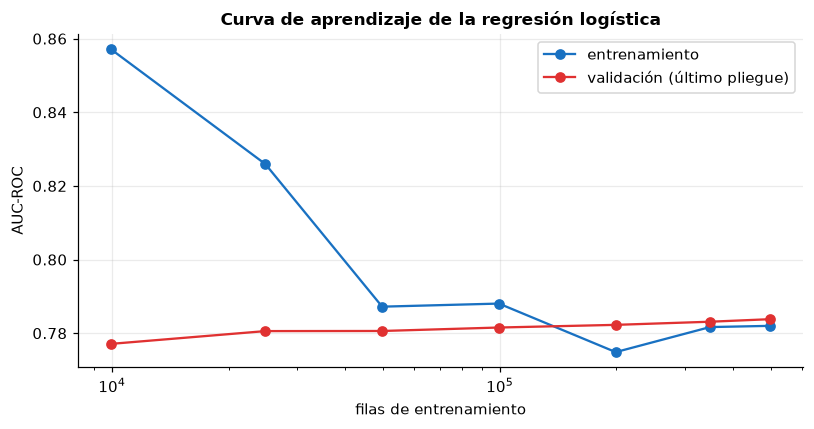

,filas,AUC train,AUC validación,brecha
0,9954,0.8571,0.7771,0.0800
1,24885,0.8259,0.7806,0.0454
2,49770,0.7872,0.7806,0.0066
3,99540,0.7880,0.7815,0.0065
4,199080,0.7749,0.7823,-0.0074
5,348390,0.7817,0.7831,-0.0015
6,497700,0.7820,0.7838,-0.0018


In [14]:
a, b = list(cv.split(train))[-1]
tam, sc_tr, sc_va = learning_curve(
    Pipeline([("prep", preprocesador()), ("clf", LogisticRegression(C=C_opt, max_iter=3000, random_state=u.SEMILLA))]),
    Xtr, y_tr, cv=[(a, b)], train_sizes=[0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0], scoring="roc_auc",
    shuffle=False, n_jobs=-1)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tam, sc_tr.mean(1), "o-", label="entrenamiento", color="#1971c2")
ax.plot(tam, sc_va.mean(1), "o-", label="validación (último pliegue)", color="#e03131")
ax.set_xscale("log")
ax.set_xlabel("filas de entrenamiento")
ax.set_ylabel("AUC-ROC")
ax.set_title("Curva de aprendizaje de la regresión logística")
ax.legend()
plt.tight_layout()
plt.show()
pd.DataFrame({"filas": tam, "AUC train": sc_tr.mean(1), "AUC validación": sc_va.mean(1),
              "brecha": sc_tr.mean(1) - sc_va.mean(1)}).round(4)

## 4.10 Interpretación de coeficientes

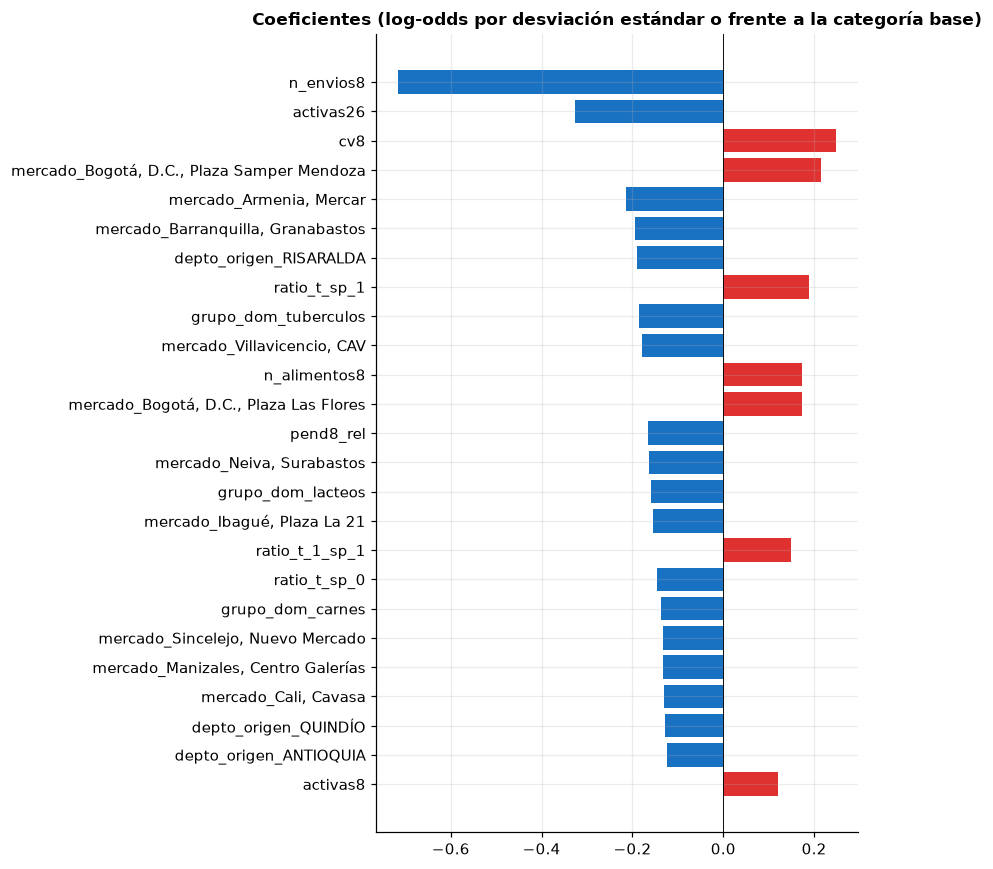

,coeficiente,odds ratio
n_envios8,-0.716,0.489
activas26,-0.327,0.721
pend8_rel,-0.166,0.847
local,-0.091,0.913
log_base8,-0.072,0.930
antig_sem,-0.043,0.958
sh_verduras,-0.038,0.963
sh_lacteos,-0.033,0.968
sh_frutas,-0.023,0.978
sh_carnes,-0.015,0.985


In [15]:
nombres = mejor.named_steps["prep"].get_feature_names_out()
coef = pd.Series(mejor.named_steps["clf"].coef_[0], index=nombres)
coef.index = coef.index.str.replace(r"^(log|spl|num|bin|cat)__", "", regex=True)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(25)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index[::-1], top.values[::-1], color=np.where(top.values[::-1] > 0, "#e03131", "#1971c2"))
ax.axvline(0, color="k", lw=0.6)
ax.set_title("Coeficientes (log-odds por desviación estándar o frente a la categoría base)")
plt.tight_layout()
plt.show()
cont = coef[[c for c in coef.index if c in LOG + NUM + BIN]]
pd.DataFrame({"coeficiente": cont, "odds ratio": np.exp(cont)}).sort_values("coeficiente").round(3)

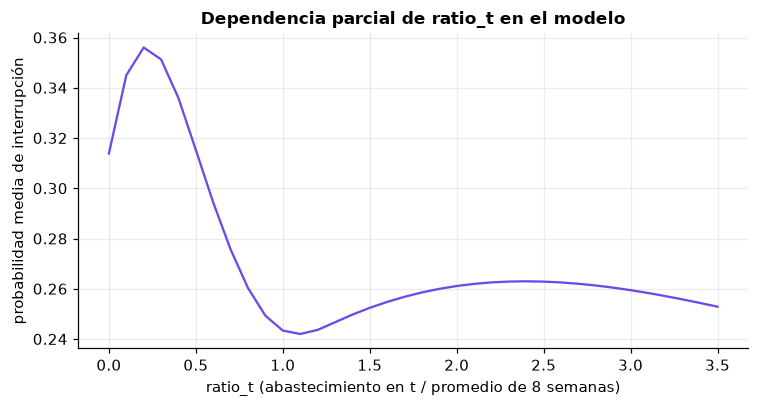

In [16]:
# Efecto de las razones de cambio (splines): probabilidad predicha al variar ratio_t
base = Xtr.sample(3000, random_state=u.SEMILLA).copy()
malla = np.linspace(0, 3.5, 36)
curva = []
for v in malla:
    base["ratio_t"] = v
    curva.append(mejor.predict_proba(base)[:, 1].mean())
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(malla, curva, color="#7048e8")
ax.set_xlabel("ratio_t (abastecimiento en t / promedio de 8 semanas)")
ax.set_ylabel("probabilidad media de interrupción")
ax.set_title("Dependencia parcial de ratio_t en el modelo")
plt.tight_layout()
plt.show()

**Interpretación.**

* **La curva de aprendizaje** se estabiliza hacia las 50 mil filas: la brecha entre entrenamiento
  y validación pasa de 0,08 con 10 mil filas a menos de 0,01 desde 50 mil, y el AUC de validación
  solo mejora de 0,781 a 0,784 al pasar de 100 mil a 500 mil filas. La muestra es más que suficiente
  para un modelo lineal; el límite del desempeño es el **sesgo del modelo** (su forma lineal), no
  el tamaño de la muestra. Los modelos no lineales de los siguientes entregables tienen margen.
* **Tamaño y regularidad** dominan: una desviación estándar más de cargas semanales
  (`n_envios8`, en log) reduce los odds de interrupción a la mitad (OR 0,49); más semanas activas en
  el semestre (`activas26`, OR 0,72) y una tendencia reciente creciente (`pend8_rel`, OR 0,85) también
  protegen; la variabilidad (`cv8`, OR 1,28) la aumenta.
* **Signos que no deben leerse aislados.** `n_alimentos8` y `activas8` tienen coeficiente positivo
  aunque su relación univariada con el objetivo es negativa. Es un efecto de supresión por
  colinealidad (correlación 0,91 con `n_envios8` y 0,83 con `activas26`, sección 2.3): a igual número
  de cargas, más productos distintos significa cargas más pequeñas y diversas. Por eso los
  coeficientes se leen en bloque.
* **Dinámica reciente.** Los splines reproducen la U del EDA: la probabilidad es máxima cuando la
  semana *t* ya trajo 10-30 % del promedio (0,36), mínima cerca del nivel habitual (0,24) y sube
  de nuevo tras un pico (0,26 alrededor de 2,5 veces el promedio).
* **Contexto.** A igualdad de lo demás, los corredores hacia las plazas minoristas de Bogotá
  (Samper Mendoza, Las Flores) tienen más riesgo y los que llegan a Armenia, Granabastos,
  Villavicencio o Neiva menos. Los corredores de tubérculos, lácteos y carnes son más estables.
  La distancia (OR 1,07 por desviación estándar) y los festivos de la semana siguiente (OR 1,07)
  aumentan ligeramente el riesgo.
* **PDET.** El coeficiente de `pdet_origen` es casi nulo (OR 0,99). La mayor tasa bruta de los
  corredores PDET (33 % frente a 28 %) se explica por sus características: son más pequeños,
  irregulares y lejanos, y están en departamentos con más interrupciones. Para la tesis esto
  indica que la fragilidad de estos corredores tiene causas logísticas (escala y regularidad) que
  una intervención puede atacar (consolidar cargas,
  acopio, regularidad de despachos).

## 4.11 Verificaciones de la nota crítica

El enunciado pide revisar el modelo si la exactitud o el R² superan 80-90 %. Se documentan las
verificaciones, aunque el modelo queda por debajo de ese rango.

In [17]:
sin_frac = [c for c in NUM if not c.startswith("frac_caida")]
def prep_sin_frac():
    ct = preprocesador()
    ct.transformers = [(n, t, [c for c in cols if not c.startswith("frac_caida")]) if n == "num" else (n, t, cols)
                       for n, t, cols in ct.transformers]
    return ct
m_sf = Pipeline([("prep", prep_sin_frac()),
                 ("clf", LogisticRegression(C=C_opt, max_iter=3000, random_state=u.SEMILLA))]).fit(Xtr, y_tr)
auc_sf = roc_auc_score(y_te, m_sf.predict_proba(Xte)[:, 1])
acc_log = tabla.loc[nombre_log, "accuracy"]
acc_dummy = tabla.loc["Dummy (clase mayoritaria)", "accuracy"]
verif = pd.Series({
    "Exactitud de la logística (umbral F1)": f"{acc_log:.3f}",
    "Exactitud de la logística (umbral 0,5)": f"{tabla.loc['Regresión logística (umbral 0,5)', 'accuracy']:.3f}",
    "Exactitud de la clase mayoritaria": f"{acc_dummy:.3f}",
    "AUC en prueba / AUC medio en validación temporal": f"{roc_auc_score(y_te, p_log):.3f} / {por_pliegue.mean():.3f}",
    "AUC sin las variables en observación frac_caida_*": f"{auc_sf:.3f}",
    "AUC univariado máximo entre predictoras admitidas": "0,753 (cv8)",
    "Validación respeta el tiempo": "sí: bloques de semanas con hueco de 8; prueba 2025 con hueco de 10",
    "Validación por bloques espaciales": f"AUC {esp['AUC-ROC'].mean():.3f}",
})
verif.to_frame("resultado")

,resultado
Exactitud de la logística (umbral F1),0.701
"Exactitud de la logística (umbral 0,5)",0.766
Exactitud de la clase mayoritaria,0.740
AUC en prueba / AUC medio en validación temporal,0.793 / 0.781
AUC sin las variables en observación frac_caida_*,0.793
AUC univariado máximo entre predictoras admitidas,"0,753 (cv8)"
Validación respeta el tiempo,sí: bloques de semanas con hueco de 8; prueba ...
Validación por bloques espaciales,AUC 0.780


**Conclusión de la nota crítica.** La exactitud (0,70-0,77) está por debajo del rango de alerta y
apenas supera la de la clase mayoritaria (0,74), por lo que se reportan métricas insensibles al
desbalance. Aun así se verificó todo lo que pide la nota: no hay fuga (ninguna predictora admitida
supera AUC univariado 0,76; las variables construidas con *t+1* están excluidas; quitar las
variables en observación `frac_caida_*` deja el AUC en 0,793), la validación respeta el tiempo con
huecos y se evaluó aparte con bloques espaciales, el AUC de prueba (0,793) es coherente con el de
validación (0,781) y los residuos no muestran dependencia temporal. El problema no es trivial: con
información de la semana actual, un modelo lineal ordena bien el riesgo (AUC 0,79) pero su precisión
en la clase positiva es moderada, lo que deja espacio para los modelos del resto del curso
(k-NN, Random Forest, XGBoost, SVM no lineal) y para variables de vecindad espacial.